In [1]:
#fn =  f"E:/000_FuJian/fnl/gdas1.fnl0p25.2024040500.f00.grib2"


In [2]:
from eccodes import *
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import cartopy.crs as crs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shapereader
from datetime import  datetime, timedelta
import os 

In [3]:
fn = r"E:/000_FuJian/ear5_tlnp/9f142d5460504cbf4017597700845a1.grib"
ds = xr.open_dataset(fn, engine='cfgrib',backend_kwargs={'filter_by_keys': {'typeOfLevel': 'isobaricInhPa'}})
ds

<xarray.Dataset> Size: 13GB
Dimensions:        (time: 96, isobaricInhPa: 37, latitude: 229, longitude: 249)
Coordinates:
    number         int32 4B ...
  * time           (time) datetime64[ns] 768B 2024-04-04 ... 2024-04-07T23:00:00
    step           timedelta64[ns] 8B ...
  * isobaricInhPa  (isobaricInhPa) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude       (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 3.5 3.25 3.0
  * longitude      (longitude) float64 2kB 73.0 73.25 73.5 ... 134.5 134.8 135.0
    valid_time     (time) datetime64[ns] 768B ...
Data variables: (12/16)
    d              (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    cc             (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    z              (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    o3             (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    pv             (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    r              (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    ...             ...
    cswc           (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    t              (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    u              (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    v              (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    w              (time, isobaricInhPa, latitude, longitude) float32 810MB ...
    vo             (time, isobaricInhPa, latitude, longitude) float32 810MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-29T14:20 GRIB to CDM+CF via cfgrib-0.9.1...

AttributeError: 'Dataset' object has no attribute 'gh'

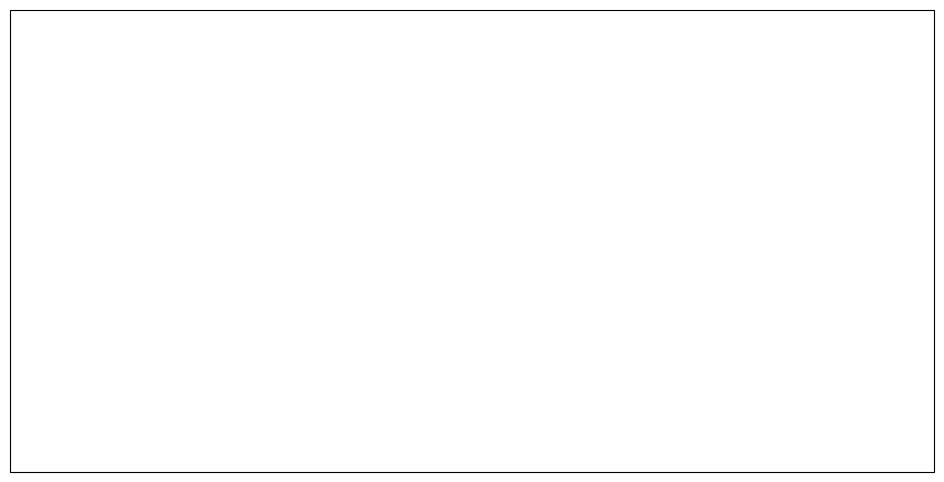

In [4]:
valid = datetime(2024,4,5,0)
title = f"level = 200 hPa, time = {valid:%Y%m%d%H}"

cart_proj = crs.PlateCarree()
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=cart_proj)
#levels = np.arange(520., 600., 4.)#500pha
levels = np.arange(1200., 1260., 4.)#200pha
gh = plt.contour(ds.longitude, ds.latitude, ds.gh.sel(isobaricInhPa=200) / 10.,
                  levels=levels, colors="blue",
                  transform=crs.PlateCarree())
plt.clabel(gh, inline=True, inline_spacing=1, fontsize=10, fmt="%i")

#levels = np.arange(-40., 40., 4.)#500pha
levels = np.arange(-60., 60., 4.)#200pha

tcontour = plt.contour(ds.longitude, ds.latitude, ds.t.sel(isobaricInhPa=200) - 273.15 ,
                  levels=levels, colors="red", 
                  transform=crs.PlateCarree())
plt.clabel(tcontour, inline=True, inline_spacing=1, fontsize=10, fmt="%i")

step = 5
wbar = ax.barbs(ds.longitude[::step], ds.latitude[::step],
            ds.u.sel(isobaricInhPa=200)[::step, ::step],
            ds.v.sel(isobaricInhPa=200)[::step, ::step],
      barb_increments={'half':2,'full':4,'flag':20},barbcolor="gray",
      transform=crs.PlateCarree(), length=5)

#extent=[115.5,120.5,23.5,28.5]  ## 经纬度范围 [西，东，南，北]
extent=[100,125,15,35] # 
#extent=[60,140,10,60] # 全国
ax.set_extent(extent)
gl = ax.gridlines(crs=crs.PlateCarree(),draw_labels=True,linewidth=0.8, color='k', alpha=0.1, linestyle='--')
gl.top_labels   = False    #关闭顶端标签
gl.right_labels = False  #关闭右侧标签
gl.xformatter = LONGITUDE_FORMATTER  #x轴设为经度格式
gl.yformatter = LATITUDE_FORMATTER   #y轴设为纬度格式
mfl    = r"E:/0_ditudate/矢量图/和鲸矢量图/province_9south.shp"
ax.add_geometries(shapereader.Reader(mfl).geometries(), crs=cart_proj, facecolor='none',edgecolor='k',linewidth=1)
plt.title(title)